# Régression Linéaire Simple avec Numpy

Implémentation from scratch d'une régression linéaire entraînée par descente de gradient, sur le dataset public **Palmer Penguins** (via seaborn).

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.linear_model import LinearRegression

# rend les figures Plotly visibles dans VS Code / JupyterLab (mimetype) comme dans
# Jupyter Notebook classique (plotly.js chargé depuis le CDN)
pio.renderers.default = 'plotly_mimetype+notebook_connected'


# 1. Dataset
On utilise le dataset public **Palmer Penguins** : 344 manchots mesurés en Antarctique. On garde une seule variable pour pouvoir tout visualiser :

- $x$ : `flipper_length_mm`, la longueur de la nageoire (en mm)
- $y$ : `body_mass_g`, la masse du manchot (en grammes)

Deux manchots n'ont pas de mesure : on les retire avec `dropna`.

Text(0, 0.5, 'Masse (g)')

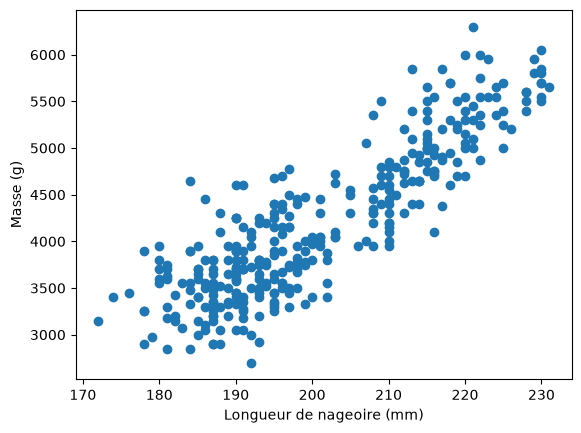

In [2]:
df = sns.load_dataset('penguins')
df = df.dropna(subset=['flipper_length_mm', 'body_mass_g'])

x = df[['flipper_length_mm']].values # tableau 2D de dimension (m, 1)
y = df['body_mass_g'].values         # vecteur 1D de dimension (m,)

plt.scatter(x, y) # x en abscisse et y en ordonnée
plt.xlabel('Longueur de nageoire (mm)')
plt.ylabel('Masse (g)')

Important : vérifier les dimensions de x et y. On remarque que y n'a pas les dimensions (m, 1). On corrige le problème avec `np.reshape`.

In [3]:
print(x.shape)
print(y.shape)

# redimensionner y
y = y.reshape(y.shape[0], 1)

print(y.shape)

(342, 1)
(342,)
(342, 1)


Création de la matrice $X$ qui contient la colonne de biais. Pour ça, on colle l'un contre l'autre le vecteur x et un vecteur de 1 (avec `np.ones`) de même dimension que x.

On l'appelle `X_brut` car x est encore dans ses unités d'origine (mm). On verra plus loin pourquoi c'est un problème.

In [4]:
X_brut = np.hstack((x, np.ones(x.shape)))
print(X_brut.shape)

(342, 2)


Finalement, création d'un vecteur paramètre $\theta$, initialisé avec des coefficients aléatoires. Ce vecteur est de dimension (2, 1) :

- $\theta_0$ (première ligne) : la **pente**, car elle multiplie la première colonne de $X$ (x)
- $\theta_1$ (deuxième ligne) : le **biais**, car il multiplie la colonne de 1

`np.random.seed(0)` permet de toujours reproduire le même vecteur $\theta$.

In [5]:
np.random.seed(0) # pour produire toujours le même vecteur theta aléatoire
theta = np.random.randn(2, 1)
theta

array([[1.76405235],
       [0.40015721]])

# 2. Modèle linéaire
On implémente un modèle $F = X.\theta$, puis on le teste pour vérifier qu'il n'y a pas de bug (bonne pratique oblige). Cela permet aussi de voir à quoi ressemble le modèle initial, défini par la valeur aléatoire de $\theta$.

In [6]:
def model(X, theta):
    return X.dot(theta)

Text(0, 0.5, 'Masse (g)')

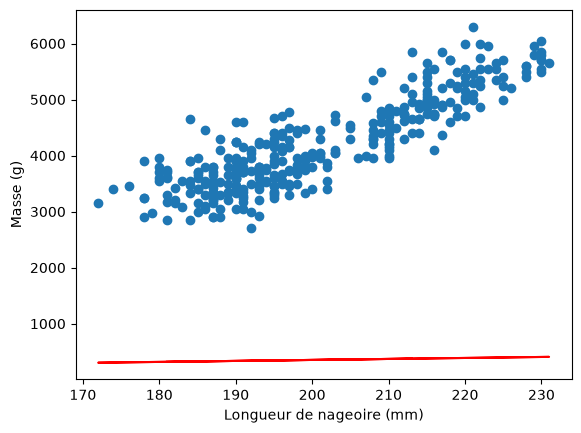

In [7]:
plt.scatter(x, y)
plt.plot(x, model(X_brut, theta), c='r')
plt.xlabel('Longueur de nageoire (mm)')
plt.ylabel('Masse (g)')

# 3. Fonction coût : erreur quadratique moyenne
On mesure les erreurs du modèle sur le dataset $(X, y)$ en implémentant l'erreur quadratique moyenne, **Mean Squared Error (MSE)** en anglais :

$ J(\theta) = \frac{1}{2m} \sum (X.\theta - y)^2 $

Le facteur $\frac{1}{2}$ n'est pas une erreur : c'est une demi-MSE. Il sert seulement à simplifier la dérivée (le 2 de l'exposant s'annule avec le $\frac{1}{2}$). Minimiser $J$ ou la MSE donne exactement le même $\theta$.

Ensuite, on teste notre fonction pour vérifier qu'il n'y a pas de bug.

In [8]:
def cost_function(X, y, theta):
    m = len(y)
    return 1/(2*m) * np.sum((model(X, theta) - y)**2)

In [9]:
cost_function(X_brut, y, theta)

np.float64(7703084.421889435)

# 4. Gradients et descente de gradient
On implémente la formule du gradient de $J$ :

$\frac{\partial J(\theta) }{\partial \theta} = \frac{1}{m} X^T.(X.\theta - y)$

Ensuite on utilise cette fonction dans la descente de gradient :

$\theta = \theta - \alpha \frac{\partial J(\theta) }{\partial \theta}$

In [10]:
def grad(X, y, theta):
    m = len(y)
    return 1/m * X.T.dot(model(X, theta) - y)

In [11]:
def gradient_descent(X, y, theta, learning_rate, n_iterations):
    
    cost_history = np.zeros(n_iterations)  # tableau pour enregistrer l'évolution du coût du modèle
    theta_history = np.zeros((n_iterations, theta.shape[0]))  # pour enregistrer theta à chaque itération
    
    for i in range(0, n_iterations):
        theta = theta - learning_rate * grad(X, y, theta) # mise à jour du paramètre theta (formule de la descente de gradient)
        cost_history[i] = cost_function(X, y, theta) # on enregistre la valeur du coût au tour i dans cost_history[i]
        theta_history[i] = theta.ravel() # on enregistre aussi la position du modèle au tour i
        
    return theta, cost_history, theta_history

# 5. Phase d'entraînement
On définit un **nombre d'itérations**, ainsi qu'un **pas d'apprentissage $\alpha$**, et c'est parti !

## 5.1 Premier essai : x dans ses unités d'origine
On lance la descente de gradient directement sur `X_brut`.

In [12]:
n_iterations = 1000
learning_rate = 0.01

with np.errstate(over='ignore', invalid='ignore'): # masque les avertissements de débordement numérique
    theta_brut, cost_history_brut, theta_history_brut = gradient_descent(X_brut, y, theta, learning_rate, n_iterations)

print('Coût aux 5 premières itérations :', cost_history_brut[:5])
print('Theta final :', theta_brut.ravel())

Coût aux 5 premières itérations : [1.23536718e+12 2.02281682e+17 3.31220425e+22 5.42347527e+27
 8.88051636e+32]
Theta final : [nan nan]


Le coût devient infini dès l'itération 57


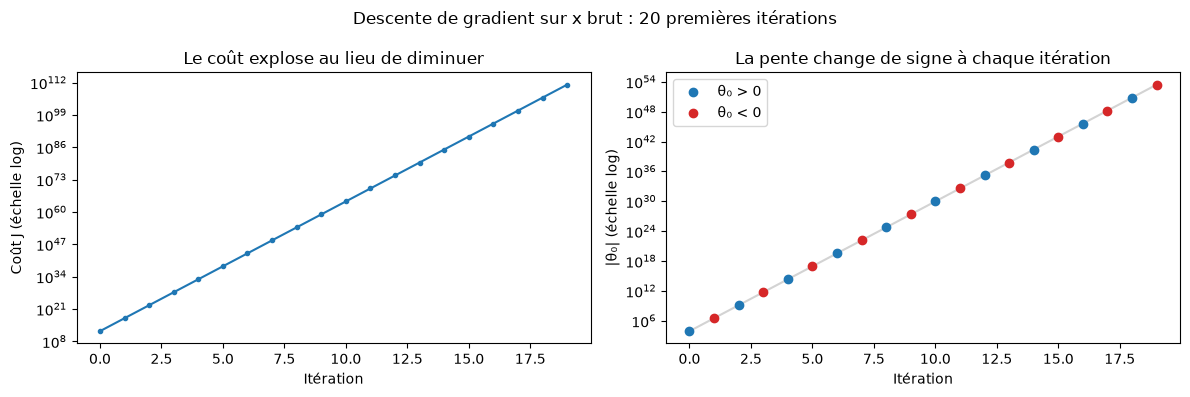

In [13]:
n_fini = np.isfinite(cost_history_brut).sum()
print(f'Le coût devient infini dès l\'itération {n_fini}')

# on zoome sur les premières itérations : au-delà, les valeurs sont trop grandes
# pour être tracées, même en échelle logarithmique
n_zoom = 20
cout_brut = cost_history_brut[:n_zoom]
pente_brut = theta_history_brut[:n_zoom, 0]
positive = pente_brut > 0

figure, (gauche, droite) = plt.subplots(1, 2, figsize=(12, 4))

# à gauche : le coût, en échelle logarithmique (sinon on ne verrait qu'un trait vertical)
gauche.semilogy(range(n_zoom), cout_brut, marker='.')
gauche.set_xlabel('Itération')
gauche.set_ylabel('Coût J (échelle log)')
gauche.set_title('Le coût explose au lieu de diminuer')

# à droite : la valeur absolue de la pente, en échelle log, colorée selon le signe
droite.semilogy(range(n_zoom), np.abs(pente_brut), color='lightgrey', zorder=1)
droite.scatter(np.where(positive)[0], np.abs(pente_brut[positive]), color='tab:blue', label='θ₀ > 0', zorder=2)
droite.scatter(np.where(~positive)[0], np.abs(pente_brut[~positive]), color='tab:red', label='θ₀ < 0', zorder=2)
droite.set_xlabel('Itération')
droite.set_ylabel('|θ₀| (échelle log)')
droite.set_title('La pente change de signe à chaque itération')
droite.legend()

figure.suptitle(f'Descente de gradient sur x brut : {n_zoom} premières itérations')
plt.tight_layout()

**Le modèle explose** : le coût grandit à chaque itération au lieu de diminuer, jusqu'à dépasser la plus grande valeur représentable par l'ordinateur (`inf`) dès l'itération 57. $\theta$ finit en `nan` (not a number).

Les deux graphiques montrent le mécanisme :

- à gauche, en échelle logarithmique, le coût monte en **ligne droite**. Une droite en échelle log, c'est une croissance exponentielle : l'erreur est multipliée par le même facteur à chaque tour
- à droite, la pente $\theta_0$ **change de signe à chaque itération** (bleu = positive, rouge = négative), tout en s'éloignant de plus en plus de 0. On trace $|\theta_0|$ pour pouvoir utiliser l'échelle log. C'est la signature d'un pas trop grand : le modèle saute par-dessus le minimum, atterrit plus loin de l'autre côté, et recommence en pire

Pourquoi ? Les nageoires mesurent environ 200 mm. Le gradient, qui contient $X^T$, est donc énorme, et chaque pas fait sauter $\theta$ bien au-delà du minimum. C'est le symptôme typique d'un **pas d'apprentissage trop grand par rapport à l'échelle des données**.

## 5.2 La solution : standardiser x
On centre et on réduit x : $x_{std} = \frac{x - \bar{x}}{\sigma_x}$. La variable est alors autour de 0, avec un écart-type de 1. On garde x d'origine pour les graphiques.

In [14]:
x_std = (x - x.mean()) / x.std()
print(x_std.mean().round(3), x_std.std().round(3))

X = np.hstack((x_std, np.ones(x_std.shape)))
print(X.shape)

-0.0 1.0
(342, 2)


On relance exactement le même entraînement, avec les mêmes hyperparamètres et le même $\theta$ initial, sur la matrice standardisée $X$.

In [15]:
theta_final, cost_history, theta_history = gradient_descent(X, y, theta, learning_rate, n_iterations)
theta_final # les paramètres du modèle une fois entraîné

array([[ 697.61198022],
       [4201.57300826]])

Text(0, 0.5, 'Masse (g)')

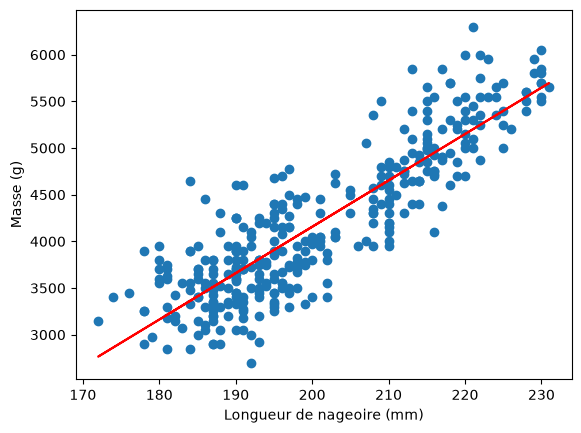

In [16]:
# vecteur qui contient les prédictions de notre modèle final
predictions = model(X, theta_final)

# prédictions (en rouge) par rapport à notre dataset (en bleu)
plt.scatter(x, y)
plt.plot(x, predictions, c='r')
plt.xlabel('Longueur de nageoire (mm)')
plt.ylabel('Masse (g)')

## 5.3 Voir la droite bouger, itération par itération
Le graphique ci-dessus ne montre que le résultat final. Avec `theta_history`, on peut rejouer tout l'entraînement : à chaque itération, la droite se rapproche du nuage de points, et $\theta$ se rapproche de sa valeur finale.

On n'affiche pas les 1000 itérations : au début tout bouge très vite, à la fin plus rien ne bouge. On échantillonne donc finement au début, puis grossièrement.

In [17]:
# itérations à afficher : fines au début (tout bouge), larges ensuite (plus rien ne bouge)
iterations_affichees = list(range(0, 50, 2)) + list(range(50, n_iterations, 25)) + [n_iterations - 1]

# la droite est entièrement définie par 2 points : ses extrémités
x_bornes = np.array([[x.min()], [x.max()]])
x_bornes_std = (x_bornes - x.mean()) / x.std()
X_bornes = np.hstack((x_bornes_std, np.ones(x_bornes_std.shape)))

def droite(i):
    """Trace de la droite du modèle telle qu'elle est à l'itération i."""
    return go.Scatter(
        x=x_bornes.ravel(),
        y=model(X_bornes, theta_history[i].reshape(-1, 1)).ravel(),
        mode='lines', line=dict(color='red', width=3), name='Modèle',
    )

def titre(i):
    t0, t1 = theta_history[i]
    return (f'Itération {i}   |   θ₀ (pente) = {t0:.1f}   |   '
            f'θ₁ (biais) = {t1:.1f}   |   coût J = {cost_history[i]:,.0f}')

nuage = go.Scatter(x=x.ravel(), y=y.ravel(), mode='markers',
                   marker=dict(size=5, color='steelblue'), name='Manchots')

fig = go.Figure(
    data=[nuage, droite(0)],
    # traces=[1] : seule la droite (index 1) est redessinée à chaque frame,
    # le nuage de points (index 0) reste en place.
    frames=[go.Frame(data=[droite(i)], traces=[1], name=str(i),
                     layout=go.Layout(title=titre(i)))
            for i in iterations_affichees],
)

fig.update_layout(
    title=titre(iterations_affichees[0]),
    xaxis_title='Longueur de nageoire (mm)',
    yaxis_title='Masse (g)',
    yaxis_range=[y.min() - 500, y.max() + 500],
    width=800, height=550,
    updatemenus=[dict(
        type='buttons',
        buttons=[
            dict(label='Play', method='animate',
                 args=[None, {'frame': {'duration': 120, 'redraw': True}, 'fromcurrent': True}]),
            dict(label='Pause', method='animate',
                 args=[[None], {'frame': {'duration': 0}, 'mode': 'immediate'}]),
        ],
    )],
    sliders=[dict(
        currentvalue={'prefix': 'Itération : '},
        steps=[dict(method='animate', label=str(i),
                    args=[[str(i)], {'frame': {'duration': 0, 'redraw': True}, 'mode': 'immediate'}])
               for i in iterations_affichees],
    )],
)

fig.show()

Ce qu'on observe en appuyant sur **Play** :

- la droite part de très bas, à plat : le $\theta$ initial est aléatoire, le modèle ne sait rien
- elle monte vers le nuage **et** pivote en même temps : $\theta_0$ et $\theta_1$ progressent à la même vitesse (40 % du chemin à l'itération 50, 87 % à l'itération 200). C'est un effet de la standardisation : les deux paramètres sont à la même échelle, donc le gradient les corrige au même rythme
- le mouvement ralentit tout seul : plus on approche du minimum, plus le gradient est petit, donc plus les pas sont courts. Le pas d'apprentissage $\alpha$, lui, n'a jamais changé
- après l'itération 400 environ, plus rien ne bouge à l'œil nu

# 6. Courbe d'apprentissage
Pour vérifier que la descente de gradient a bien fonctionné, on observe l'évolution de la fonction coût au fil des itérations. On doit obtenir une courbe qui diminue à chaque itération, puis qui se stabilise à un niveau minimal. Ce minimum n'est pas zéro sur des données réelles : une droite ne peut pas passer par tous les points.

Si la courbe remonte ou devient infinie, le **learning_rate** est trop élevé (c'est ce qu'on a vu en 5.1).

Text(0, 0.5, 'Coût J')

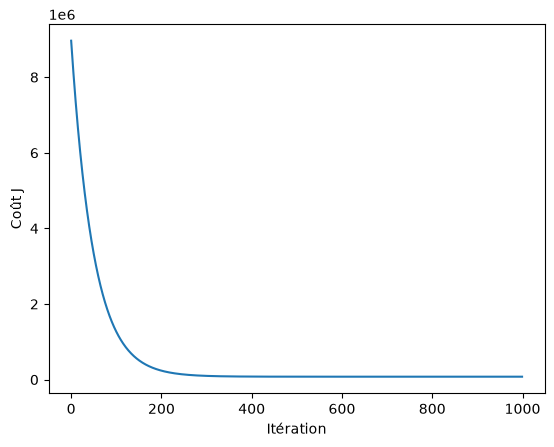

In [18]:
plt.plot(range(n_iterations), cost_history)
plt.xlabel('Itération')
plt.ylabel('Coût J')

La courbe est plate dès environ 400 itérations : les 600 suivantes n'apportent plus rien. On pourrait réduire `n_iterations`, ou augmenter `learning_rate` pour converger plus vite.

# 7. Interpréter et vérifier le modèle
## 7.1 Revenir aux unités réelles
$\theta$ a été appris sur x standardisé : la pente vaut donc « grammes par écart-type de nageoire », ce qui ne parle à personne. On la convertit en unités réelles :

- pente réelle = $\frac{\theta_0}{\sigma_x}$
- biais réel = $\theta_1 - \text{pente réelle} \times \bar{x}$

In [19]:
pente = theta_final[0, 0] / x.std()
biais = theta_final[1, 0] - pente * x.mean()

print(f'Pente : {pente:.1f} g par mm de nageoire')
print(f'Biais : {biais:.1f} g')

Pente : 49.7 g par mm de nageoire
Biais : -5780.6 g


Lecture : **chaque millimètre de nageoire en plus correspond à environ 50 g de masse en plus**.

Le biais négatif (masse d'un manchot à nageoire de 0 mm) n'a pas de sens physique : il sert juste à placer la droite. Un modèle linéaire n'est valable que dans la plage des données observées (ici 172 à 231 mm).

## 7.2 Vérifier avec scikit-learn
Notre code est fait main : comment savoir s'il est juste ? On compare avec `LinearRegression` de scikit-learn, qui calcule la solution exacte directement sur x brut.

In [20]:
reference = LinearRegression().fit(x, y)

print(f'Notre modèle : pente = {pente:.2f}, biais = {biais:.2f}')
print(f'scikit-learn : pente = {reference.coef_[0, 0]:.2f}, biais = {reference.intercept_[0]:.2f}')

Notre modèle : pente = 49.68, biais = -5780.58
scikit-learn : pente = 49.69, biais = -5780.83


Les deux modèles trouvent les mêmes coefficients : notre implémentation est correcte.

# 8. Évaluation finale
## 8.1 Coefficient de détermination $R^2$
Pour évaluer la performance du modèle avec une métrique connue, on utilise le **coefficient de détermination** $R^2$. Il mesure la part de la variance de y expliquée par le modèle :

- $R^2 = 1$ : prédictions parfaites
- $R^2 = 0$ : le modèle ne fait pas mieux que prédire toujours la moyenne de y
- $R^2 < 0$ : le modèle fait **pire** que la moyenne (c'est possible !)

In [21]:
def coef_determination(y, pred):
    u = ((y - pred)**2).sum()
    v = ((y - y.mean())**2).sum()
    return 1 - u/v

In [22]:
coef_determination(y, predictions)

np.float64(0.7589924666470083)

## 8.2 Erreur en grammes
Le $R^2$ est abstrait. Pour parler à un client, on exprime l'erreur dans l'unité de y :

- **MAE** (erreur absolue moyenne) : de combien on se trompe en moyenne
- **RMSE** (racine de la MSE) : pareil, mais pénalise plus les grosses erreurs

In [23]:
mae = np.abs(y - predictions).mean()
rmse = np.sqrt(((y - predictions)**2).mean())

print(f'MAE  : {mae:.0f} g')
print(f'RMSE : {rmse:.0f} g')

MAE  : 313 g
RMSE : 393 g


En moyenne, on se trompe d'environ 300 g sur un manchot d'environ 4 kg.

**Attention** : ces scores sont calculés sur les données qui ont servi à entraîner le modèle. Ils sont donc optimistes. Pour mesurer la performance sur de nouveaux manchots, il faut évaluer sur des données non vues (découpage train/test, validation croisée) : c'est l'objet du TP 01.

# 9. Limite du modèle : l'espèce
Le dataset contient trois espèces de manchots. Colorons les points par espèce.

Text(0, 0.5, 'Masse (g)')

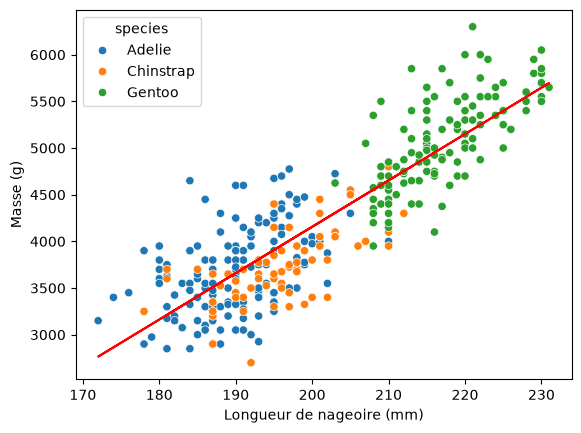

In [24]:
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.plot(x, predictions, c='r')
plt.xlabel('Longueur de nageoire (mm)')
plt.ylabel('Masse (g)')

In [25]:
# résidu = valeur réelle - prédiction. Résidu moyen positif = le modèle sous-estime l'espèce
df['residu'] = (y - predictions).ravel()
df.groupby('species')['residu'].mean().round(0)

species
Adelie        44.0
Chinstrap   -216.0
Gentoo        66.0
Name: residu, dtype: float64

Les erreurs ne sont pas réparties au hasard : le modèle **surestime** les Chinstrap d'environ 200 g en moyenne. À longueur de nageoire égale, ils sont plus légers que les autres espèces. Une seule droite ne peut pas capter cette différence.

# Pour aller plus loin
Ajouter d'autres variables (régression multiple) : la matrice $X$ aura alors une colonne par variable, plus la colonne de biais. L'espèce, qui est une variable catégorielle, devra d'abord être encodée en colonnes numériques (one-hot encoding). Le code de `model`, `cost_function` et `grad` reste identique : c'est la force de l'écriture matricielle.